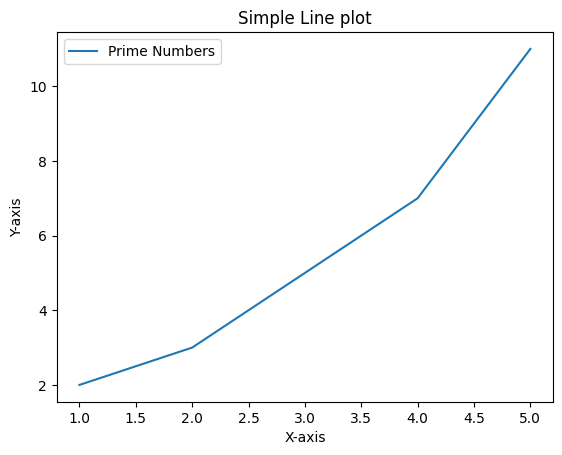

In [2]:
import matplotlib.pyplot as plt

x = [1,2,3,4,5]
y = [2,3,5,7,11]

plt.plot(x,y, label = "Prime Numbers")

# Adding title and labels
plt.title("Simple Line plot")
plt.xlabel('X-axis')
plt.ylabel("Y-axis")

# adding a legend
plt.legend()

plt.show()          # displaying the plot

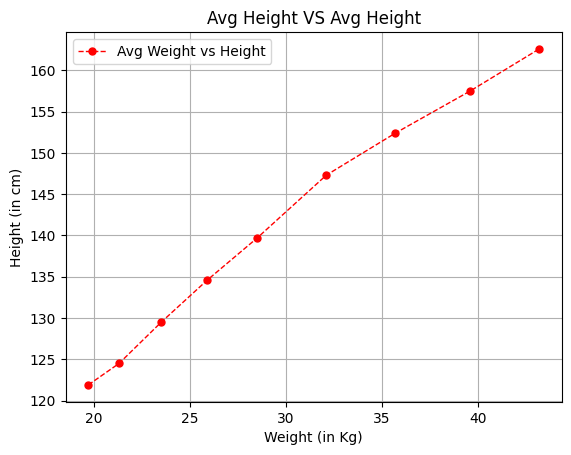

In [3]:
weight = [19.7, 21.3, 23.5, 25.9, 28.5, 32.1, 35.7, 39.6, 43.2]
height = [121.9, 124.5, 129.5, 134.6, 139.7, 147.3, 152.4, 157.5,162.6]

plt.plot(weight, height, color ='red', marker ='o', markersize =5, linestyle ='--', linewidth = 1, label = 'Avg Weight vs Height')

plt.title('Avg Height VS Avg Height')
plt.xlabel('Weight (in Kg)')
plt.ylabel('Height (in cm)')

plt.grid()
plt.legend()

plt.show()

In [4]:
import pandas as pd

df_customers = pd.read_csv('Customers.csv')
df_products = pd.read_csv('Products.csv')
df_purchases = pd.read_csv('Purchase.csv')

In [5]:
# check if any null present in customers dataset

df_customers.isnull().sum()

id               0
first_name       0
last_name        0
email            0
gender           0
street_num       0
street_name      0
street_suffix    0
city             0
state            0
postcode         0
dtype: int64

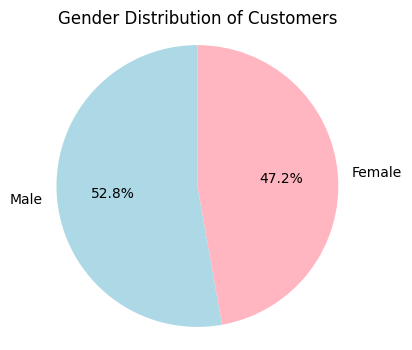

In [ ]:
                                                # Gender Distribution
gender_count = df_customers['gender'].value_counts()            # value_counts() used to count no. of occurences of each unique value

plt.figure(figsize = (4,4))                                     # (4,4) is size in inches length nad width
plt.pie(gender_count, labels= gender_count.index, autopct = '%1.1f%%', startangle = 90, colors = ['lightblue', 'lightpink'])
# autopct = '%1.1f%%' is used to display percentage on the pie chart, startangle = 90 is used to start the pie chart from 90 degree, colors is used to specify the colors of the pie chart
# if we write 2.2f%% then it will display percentage with 2 decimal places

plt.title('Gender Distribution of Customers')
plt.axis('equal')                                               # to make the pie chart circular
plt.show()

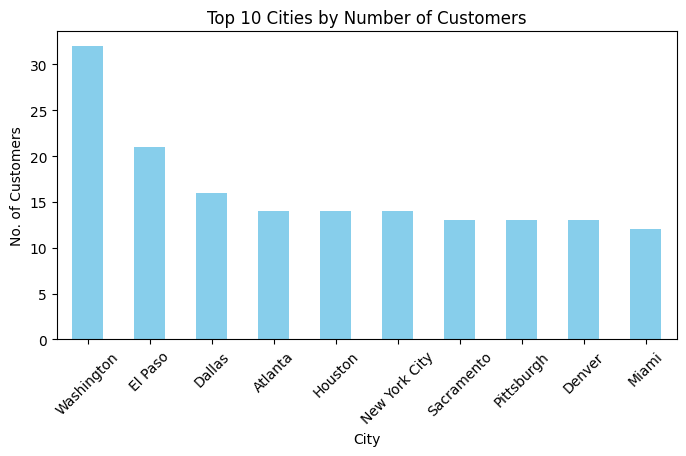

In [ ]:
                                                # Location Analysis
city_counts = df_customers['city'].value_counts().head(10)
plt.figure(figsize = (8,4))
city_counts.plot(kind = 'bar', color='skyblue')              # 

plt.title('Top 10 Cities by Number of Customers')
plt.xlabel('City')
plt.ylabel('No. of Customers')
plt.xticks(rotation=45)                         # Rotate x-axis labels for better readability
plt.show()

In [ ]:
                                                # Customer Spending Pattern (monthwise)
# converting 'purch_date' to datetime format
df_purchases['purch_date'] = pd.to_datetime(df_purchases['purch_date'])

df_purchases['month'] = df_purchases['purch_date'].dt.month

monthly_spending = df_purchases.groupby('month')['amount'].sum().reset_index()
monthly_spending.head()                                                     # we can see the difference in the output of below two cells

,month,amount
0,1,2643
1,2,1713
2,3,16752
3,4,14268
4,5,10537


In [21]:
monthly_spending2 = df_purchases.groupby('month')['amount'].sum()
monthly_spending2.head()

month
1     2643
2     1713
3    16752
4    14268
5    10537
Name: amount, dtype: int64

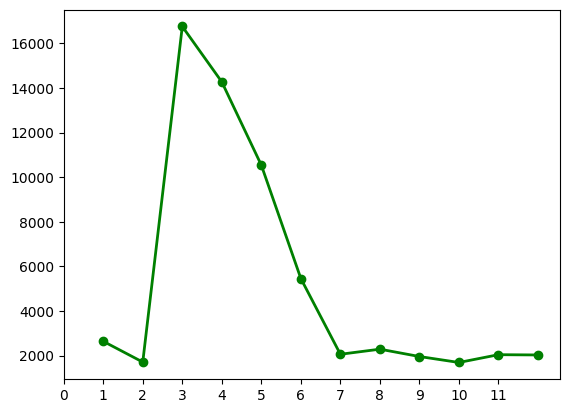

In [24]:
plt.plot(monthly_spending2.index, monthly_spending2.values, marker='o', color='green', linestyle='-', linewidth=2)
plt.xticks(monthly_spending.index)
plt.show()

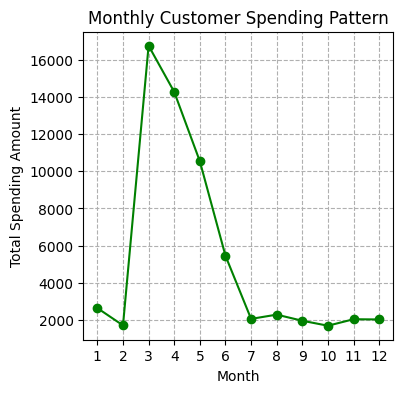

In [27]:
plt.figure(figsize=(4,4))
plt.plot(monthly_spending['month'], monthly_spending['amount'], marker='o', color='green')
plt.title('Monthly Customer Spending Pattern')
plt.xlabel('Month')
plt.ylabel('Total Spending Amount')
plt.xticks(monthly_spending['month'])
plt.grid(True, linestyle = '--')
plt.show()

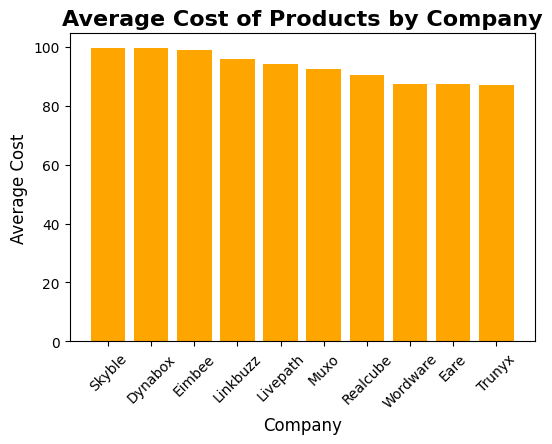

In [32]:
                                                # cost distribution by company 
avg_cost_by_company = df_products.groupby('company')['cost'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(6,4))
plt.bar(avg_cost_by_company['company'],avg_cost_by_company['cost'], color='orange')

plt.title('Average Cost of Products by Company', fontsize =16, fontweight = 'bold')
plt.xlabel('Company', fontsize = 12)
plt.ylabel('Average Cost', fontsize = 12)
plt.xticks(rotation=45)

plt.show()

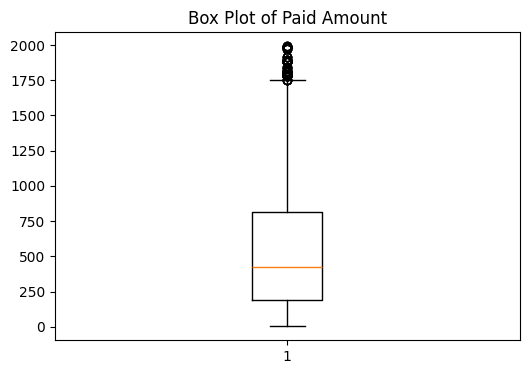

In [33]:
                                            # box plot of paid column 
plt.figure(figsize = (6,4))
plt.boxplot(df_purchases['paid'])

plt.title('Box Plot of Paid Amount')
plt.show()

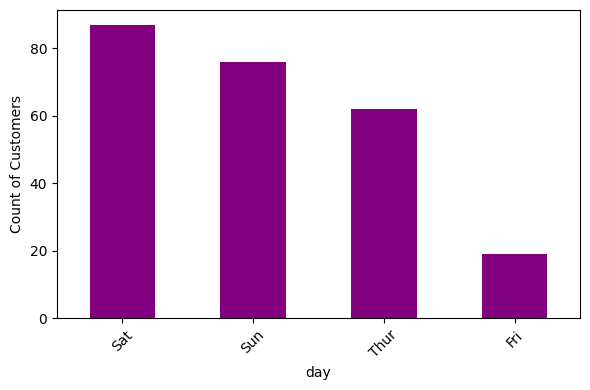

In [6]:
# count of customers by day

import matplotlib.pyplot as plt
import pandas as pd

tips = pd.read_csv('tips.csv')
data= tips['day'].value_counts()

plt.figure(figsize = (6,4))
data.plot(kind = 'bar', color = 'purple')

plt.ylabel('Count of Customers')
plt.xticks(rotation =45)
plt.tight_layout()          # to adjust the layout of the plot
plt.show()

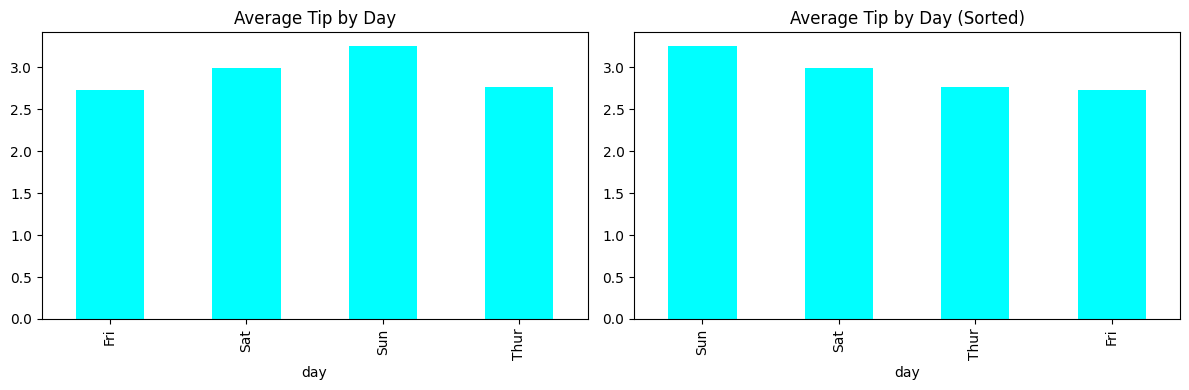

In [18]:
# Average Tip Amount 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

tips.groupby('day')['tip'].mean().plot(kind='bar', color='cyan', ax=ax1)
ax1.set_title('Average Tip by Day')

tips.groupby('day')['tip'].mean().sort_values(ascending=False).plot(kind='bar', color='cyan', ax=ax2)
ax2.set_title('Average Tip by Day (Sorted)')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Gender Distribution')

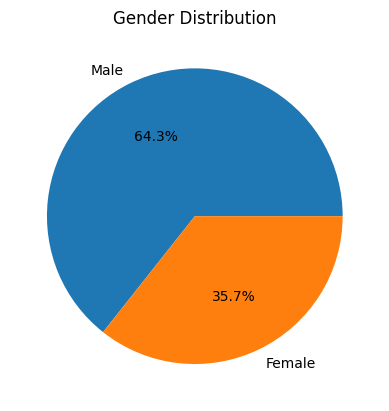

In [21]:

gender_distribution = tips['sex'].value_counts()
plt.pie(gender_distribution, labels=gender_distribution.index, autopct='%1.1f%%')
plt.title('Gender Distribution')

Gender Distribution on Weekdays:
sex
Female    41
Male      40
Name: count, dtype: int64




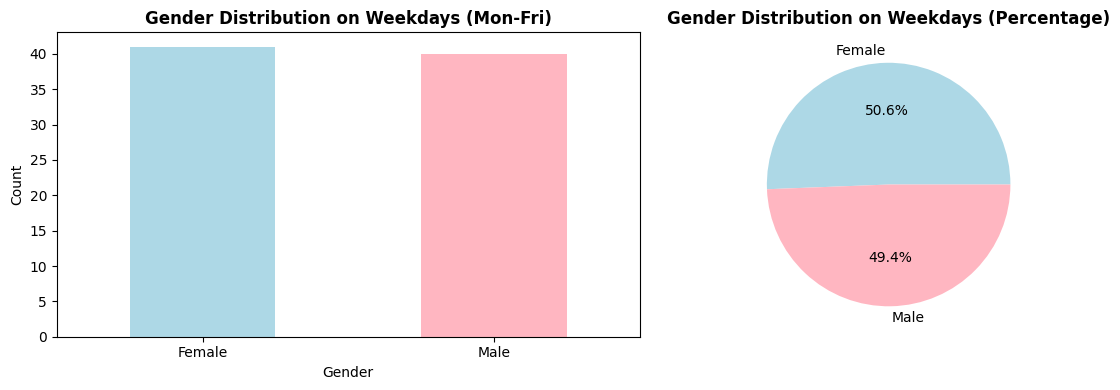

Gender with higher presence on weekdays: Female (41 customers)


In [29]:
# Gender Distribution on Weekdays (Thursday and Friday only - available weekdays in dataset)

# Define weekdays (only Thu and Fri are available in the dataset)
weekdays = ['Thur', 'Fri']

# Filter data for weekdays only
tips_weekdays = tips[tips['day'].isin(weekdays)]

# Count gender distribution on weekdays
gender_weekdays = tips_weekdays['sex'].value_counts()

print("Gender Distribution on Weekdays:")
print(gender_weekdays)
print("\n")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
gender_weekdays.plot(kind='bar', color=['lightblue', 'lightpink'], ax=ax1)
ax1.set_title('Gender Distribution on Weekdays (Mon-Fri)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)

# Pie chart
ax2.pie(gender_weekdays, labels=gender_weekdays.index, autopct='%1.1f%%', colors=['lightblue', 'lightpink'])
ax2.set_title('Gender Distribution on Weekdays (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Find which gender has higher presence
higher_gender = gender_weekdays.idxmax()
higher_count = gender_weekdays.max()
print(f"Gender with higher presence on weekdays: {higher_gender} ({higher_count} customers)")

In [28]:
tips['day'].unique()

array(['Sun', 'Sat', 'Thur', 'Fri'], dtype=object)

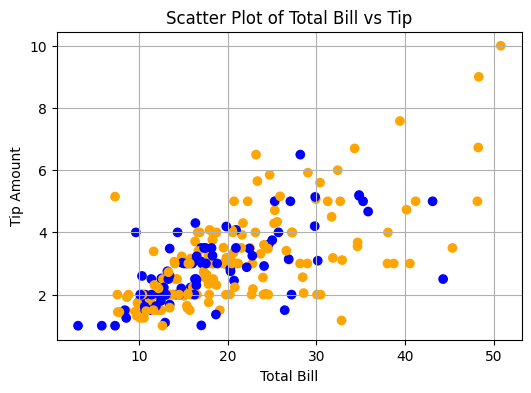

In [32]:
# scatter plot of total bill vs tip

plt.figure(figsize = (6,4))
plt.scatter(tips['total_bill'], tips['tip'], c=tips['sex'].map({'Male': 'Orange', 'Female': 'Blue'}))
plt.title('Scatter Plot of Total Bill vs Tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip Amount')
plt.grid()
plt.show()

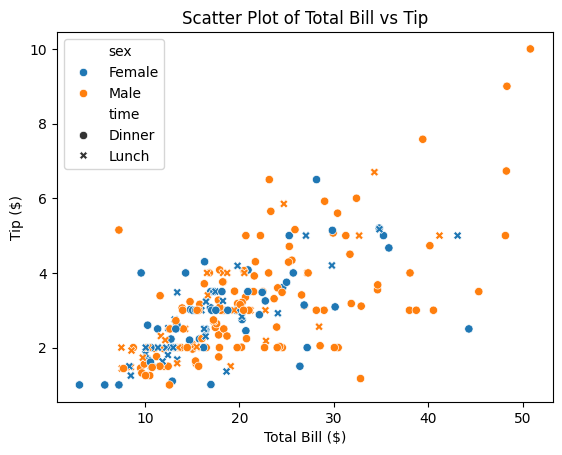

In [36]:
# Create a scatter plot for total bill vs tip
import seaborn as sns
sns.scatterplot(x='total_bill', y='tip', data=tips, hue='sex', style='time')
# Set the title and labels
plt.title('Scatter Plot of Total Bill vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
# Display the plot
plt.show()